In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape

(100, 4)

In [ ]:
df = pd.read_csv('/content/placement.csv') # Re-load the original DataFrame
df = df.iloc[:,1:] # Then apply the column selection

In [ ]:
import matplotlib.pyplot as plt

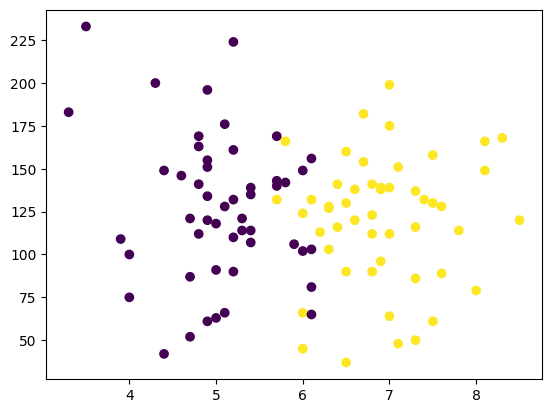

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
y.shape

(100,)

In [ ]:
X.shape

(100, 2)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [ ]:
X_train

,cgpa,iq
41,5.4,114.0
74,6.7,154.0
28,5.2,90.0
71,6.1,132.0
16,5.2,224.0
...,...,...
88,4.4,149.0
55,7.8,114.0
57,6.5,130.0
92,5.2,110.0


In [ ]:
y_train

,placement
41,0
74,1
28,0
71,1
16,0
...,...
88,0
55,1
57,1
92,0


In [ ]:
X_test

,cgpa,iq
18,4.0,100.0
77,7.3,50.0
53,8.3,168.0
11,6.9,138.0
35,6.8,90.0
98,6.3,103.0
9,5.1,66.0
82,6.5,37.0
69,8.5,120.0
30,7.6,128.0


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
Scalar = StandardScaler()

In [ ]:
X_train = Scalar.fit_transform(X_train)

In [ ]:
X_train

array([[-0.46813335, -0.3129298 ],
       [ 0.72775315,  0.71306955],
       [-0.65211588, -0.92852941],
       [ 0.17580554,  0.14876991],
       [-0.65211588,  2.50856842],
       [-0.83609842, -1.62107898],
       [ 1.27970076, -1.03112935],
       [ 0.54377061, -0.92852941],
       [ 0.08381427, -0.62072961],
       [-0.92808969, -0.1590299 ],
       [ 1.00372696,  1.86731882],
       [ 0.91173569,  0.32831979],
       [-0.19215954,  1.09781931],
       [ 0.17580554,  0.76436952],
       [ 1.09571822,  0.6361196 ],
       [-0.65211588,  0.14876991],
       [ 0.45177934,  0.37961976],
       [-0.19215954,  0.43091973],
       [-0.92808969,  0.20006987],
       [-0.10016827,  0.40526974],
       [-2.21596745,  2.73941827],
       [-1.02008096,  0.37961976],
       [ 0.81974442, -0.36422977],
       [-0.74410715,  1.27736919],
       [ 1.4636833 , -1.67237894],
       [-0.83609842, -0.90287943],
       [-0.56012461, -0.13337992],
       [ 1.09571822, -2.00582873],
       [ 0.81974442,

In [ ]:
X_test = Scalar.transform(X_test)

In [ ]:
X_test

array([[-1.75601111, -0.67202958],
       [ 1.27970076, -1.95452877],
       [ 2.19961345,  1.07216932],
       [ 0.91173569,  0.30266981],
       [ 0.81974442, -0.92852941],
       [ 0.35978807, -0.59507962],
       [-0.74410715, -1.54412903],
       [ 0.54377061, -2.28797856],
       [ 2.38359599, -0.1590299 ],
       [ 1.55567457,  0.04616997]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
#modeltrain
clf.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
y_test

,placement
18,0
77,1
53,1
11,1
35,1
98,1
9,0
82,1
69,1
30,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

1.0

In [ ]:
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions

ERROR: Operation cancelled by user


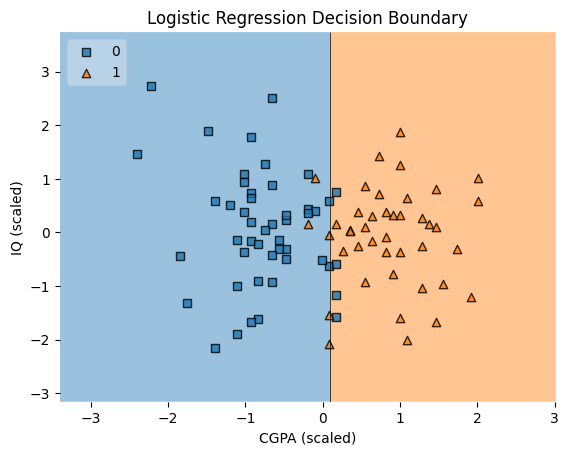

In [ ]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)
plt.xlabel('CGPA (scaled)')
plt.ylabel('IQ (scaled)')
plt.title('Logistic Regression Decision Boundary')
plt.show()

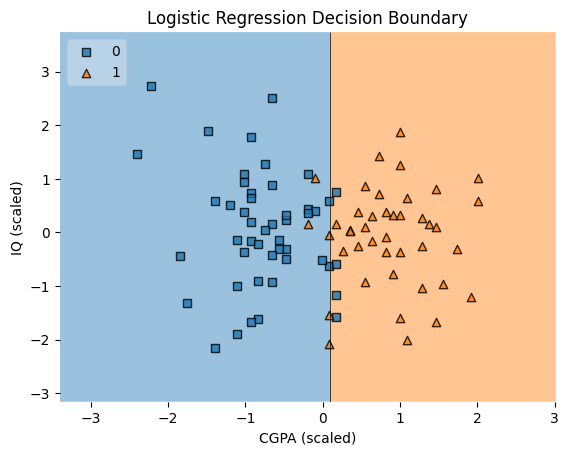

In [ ]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)
plt.xlabel('CGPA (scaled)')
plt.ylabel('IQ (scaled)')
plt.title('Logistic Regression Decision Boundary')
plt.show()

In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))